# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-3B** với LoRA/QLoRA trên Vietnamese dataset,  
so sánh rank `r=8`, `r=16`, `r=64`, và hoàn thành **tất cả bonus tasks**.

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-3B-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | `"no"` (T4 VRAM limited) |
| Max seq length cap | 1024 |
| Dataset samples | 200 |
| Estimated time | ~60 phút trên T4 |

> ⚠️ **T4-specific tweaks**: tắt eval-during-training, batch=1, manual eval fallback.

## Lab Roadmap — Full Bonus Edition

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset prep (Alpaca, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Load Qwen2.5-3B 4-bit + Wrap LoRA | model |
| 3 | Train baseline `r=16` | adapter checkpoint |
| 4 | Rank experiment — `r=8` và `r=64` | 2 checkpoints |
| 5 | Evaluate — perplexity + qualitative | metrics |
| 🎁 | **Bonus A** — ALL layers vs q+v ablation (best practice 2025) | so sánh ppl |
| 🎁 | **Bonus B** — 20 qualitative examples (vs 5 mặc định) | CSV 20 rows |
| 🎁 | **Bonus C** — GGUF export + llama.cpp deploy | `.gguf` file |
| 🎁 | **Bonus D** — Multi-tenant adapter swap demo | latency metrics |
| 🎁 | **Bonus E** — Push adapter + GGUF lên HuggingFace Hub | HF repo URL |
| 6 | Final report + cost estimate | `rank_experiment_summary.csv` |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8, r=16, r=64`)
2. **Evaluation report**: training time, peak VRAM, eval perplexity, 20 qualitative before/after, training cost, rank trade-off conclusion
3. **Bonus**: ablation table (ALL layers vs q+v), GGUF file, HF Hub link


## 0. Setup & Environment Check

In [ ]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 03:09:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU — sẽ nhanh hơn!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) sẽ chạy được.")


✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128


In [ ]:
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas huggingface_hub
print("✓ Packages installed")


In [ ]:
# Optional: mount Google Drive to save checkpoints persistently
MOUNT_DRIVE = False  # ← đổi thành True nếu muốn save vào Drive

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4'
else:
    OUTPUT_DIR = '/content/lab21_lora_t4'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")


✓ Output dir: /content/lab21_lora_t4


## 1. Dataset Preparation

Chuẩn bị 200 examples Alpaca format từ Vietnamese GPT-4 dataset.  
**Option A** (mặc định): load từ HuggingFace. **Option B**: dùng data riêng.


In [ ]:
# ─── Option A: load Vietnamese Alpaca dataset từ HuggingFace ───
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(200))
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

alpaca_gpt4_data_vi.json:   0%|          | 0.00/102M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

✓ Loaded 200 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [ ]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")


In [ ]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])


✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

Token length distribution:
  min=25, max=738
  p50=227, p95=562, p99=704

✓ Chọn max_seq_length = 1024 (cap = 1024)


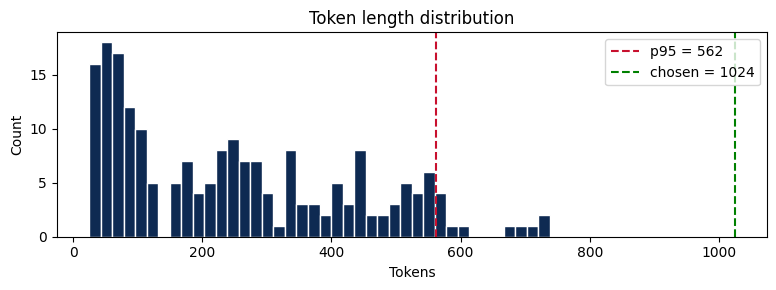

In [ ]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME  = "unsloth/Qwen2.5-3B-bnb-4bit"
MAX_SEQ_CAP = 1024  # hard cap cho T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'token_dist.png'), dpi=120)
plt.show()


In [ ]:
# 90/10 train/eval split
split    = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds  = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")


✓ Train: 180  |  Eval: 20


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4).

**LoRA config baseline:**
- `r=16`, `lora_alpha=32` (alpha/r = 2)
- `target_modules=["q_proj","v_proj"]` — lab spec (so sánh với ALL layers ở Bonus A)
- `use_gradient_checkpointing="unsloth"` — -60% VRAM, +20% time


In [ ]:
from unsloth import FastLanguageModel
import time, gc

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = MODEL_NAME,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype          = None,       # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit   = True,       # QLoRA — NF4 quantization
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha, target_all=False):
    """Wrap model với LoRA adapter.

    target_all=False → chỉ q+v (lab spec gốc)
    target_all=True  → ALL attention + FFN layers (Bonus A — best practice 2025)
    """
    if target_all:
        target_modules = ["q_proj","k_proj","v_proj","o_proj",
                          "gate_proj","up_proj","down_proj"]
    else:
        target_modules = ["q_proj","v_proj"]   # lab spec mặc định

    return FastLanguageModel.get_peft_model(
        model,
        r                          = r,
        lora_alpha                 = alpha,
        target_modules             = target_modules,
        lora_dropout               = 0,
        bias                       = "none",
        use_gradient_checkpointing = "unsloth",  # -60% VRAM
        random_state               = 42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")
print(f"✓ VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 3,686,400 (0.217% of 1,702,359,040)
✓ VRAM used: 2.12 GB


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR, warmup 10%
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: `"no"` — T4 không đủ VRAM cho mid-train eval
- `safe_evaluate()` — manual eval fallback chống OOM


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Fix: alias tokenizer→processing_class cho old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS      = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY       = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS     = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD   = "dataset_text_field" in _SFT_PARAMS
print(f"✓ eval kwarg key: '{_EVAL_KEY}'")

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir                 = os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size= 1,
        per_device_eval_batch_size = 1,
        eval_accumulation_steps    = 4,
        prediction_loss_only       = True,
        gradient_accumulation_steps= 8,
        warmup_ratio               = 0.10,
        num_train_epochs           = 3,
        learning_rate              = 2e-4,
        lr_scheduler_type          = "cosine",
        fp16                       = not torch.cuda.is_bf16_supported(),
        bf16                       = torch.cuda.is_bf16_supported(),
        logging_steps              = 5,
        eval_steps                 = 25,
        save_strategy              = "epoch",
        optim                      = "adamw_8bit",
        weight_decay               = 0.01,
        seed                       = 42,
        report_to                  = "none",
    )
    base_kwargs[_EVAL_KEY] = "no"   # T4 VRAM limitation
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra  = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra  = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args       = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — xử lý NotebookProgressCallback bug + OOM."""
    gc.collect(); torch.cuda.empty_cache()
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Manual eval...")
    gc.collect(); torch.cuda.empty_cache()
    m = trainer.model; m.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in trainer.get_eval_dataloader():
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out    = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)


trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched
✓ eval kwarg key: 'eval_strategy'


In [ ]:
# ── Train baseline r=16 ──────────────────────────────────────────────────────
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0        = time.time()
result_16 = trainer_16.train()
wall_16   = time.time() - t0
vram_16   = torch.cuda.max_memory_allocated() / 1e9
trainable_16 = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16       = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval_loss={eval_loss_16:.4f}, perplexity={ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN.")
    eval_loss_16 = float("nan")
    ppl_16       = float("nan")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,686,400 of 3,089,625,088 (0.12% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.614305
10,1.573560
15,1.606689
20,1.555441
25,1.479080
30,1.416185
35,1.496181
40,1.480136
45,1.380218
50,1.388354


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-69/tokenizer_config.json.


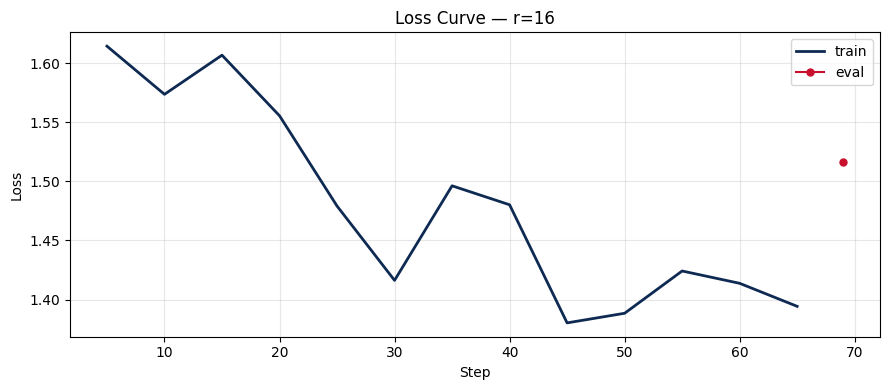


📌 T4 mode: eval-during-training tắt. Chỉ có train loss curve.


In [ ]:
# ── Plot training loss ───────────────────────────────────────────────────────
import pandas as pd

def plot_losses(log_history, title="Training Loss", save_path=None):
    df    = pd.DataFrame(log_history)
    train = df[df["loss"].notna()]     if "loss"      in df.columns else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df.columns else pd.DataFrame()
    plt.figure(figsize=(9, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"],      label="train", color="#0E2A52", lw=2)
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval",  color="#C8102E", marker="o", ms=5)
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16",
            save_path=os.path.join(OUTPUT_DIR, "loss_r16.png"))
print("\n📌 T4 mode: eval-during-training tắt. Chỉ có train loss curve.")


## 4. Rank Experiment — `r=8` vs `r=64`

Train thêm 2 adapters để so sánh 4 chiều:
- **`r=8`** — 0.05% params, train nhanh, ít VRAM nhất
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM nhất


In [16]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics dict."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m           = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable   = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save BEFORE eval — eval may OOM but checkpoint must be kept
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting NaN.")
        eval_loss = float("nan")

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float("nan"),
        "trainer": tr, "model": m, "tokenizer": tok,
    }


In [17]:
# Cleanup baseline trước khi train rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)



========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/180 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 3,087,781,888 (0.06% trained)


Step,Training Loss
5,1.616500
10,1.591786
15,1.633090
20,1.581143
25,1.512532
30,1.451584
35,1.532159
40,1.516283
45,1.417545
50,1.441451


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/tokenizer_config.json.


✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [18]:
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)



========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,745,600 of 3,100,684,288 (0.48% trained)


Step,Training Loss
5,1.601615
10,1.524071
15,1.547107
20,1.504727
25,1.425420
30,1.345464
35,1.402454
40,1.381225
45,1.297632
50,1.270547


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/tokenizer_config.json.


✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [19]:
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32,  "trainable_params": trainable_16,
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items()  if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df[["rank","trainable_params","train_time_min",
                   "peak_vram_gb","eval_loss","eval_perplexity"]].to_string(index=False))
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)



=== Rank Experiment Summary ===
 rank  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8           1843200        4.128510      7.216138   1.557694         4.747861
   16           3686400        4.217383      6.617750   1.516083         4.554353
   64          14745600        4.037241      7.998512   1.476811         4.378959


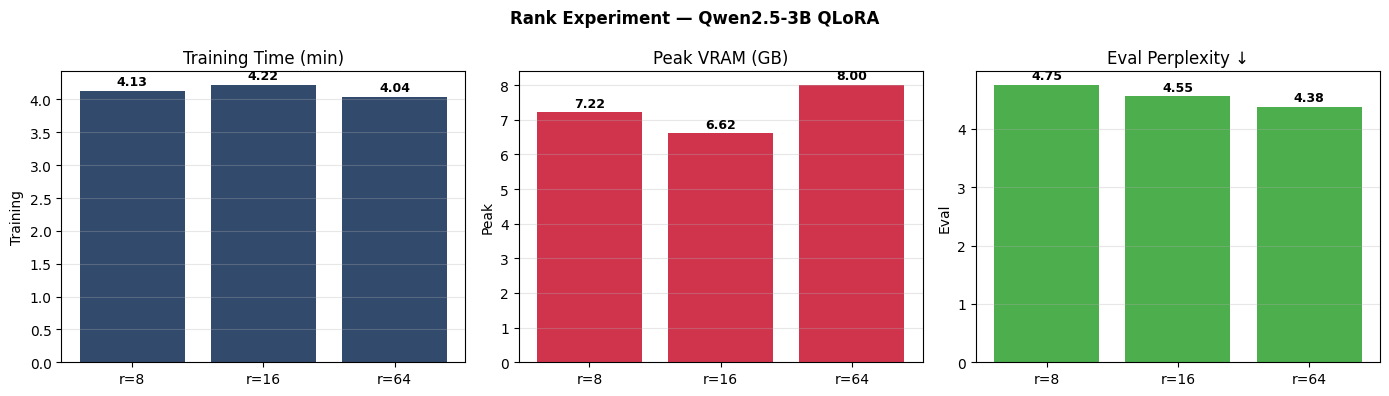

In [20]:
# ── Visualize rank trade-offs ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ("train_time_min",   "Training Time (min)"),
    ("peak_vram_gb",     "Peak VRAM (GB)"),
    ("eval_perplexity",  "Eval Perplexity ↓"),
]
colors = ["#0E2A52", "#C8102E", "#2ca02c"]

for ax, (col, label), color in zip(axes, metrics, colors):
    vals = summary_df[col].tolist()
    bars = ax.bar([f"r={r}" for r in summary_df["rank"]], vals, color=color, alpha=0.85)
    ax.set_title(label); ax.set_ylabel(label.split()[0])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Rank Experiment — Qwen2.5-3B QLoRA", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rank_comparison.png"), dpi=120)
plt.show()


## 5. Evaluation — Qualitative Comparison (5 prompts mặc định)

In [21]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
    "Giải thích overfitting và cách phòng tránh.",
    "Viết hàm Python kiểm tra số nguyên tố.",
    "Tại sao gradient vanishing xảy ra trong deep network?",
    "Batch normalization vs layer normalization — khác nhau thế nào?",
    "Giải thích attention mechanism trong Transformer.",
    "Tóm tắt ưu/nhược điểm của mô hình MoE (Mixture of Experts).",
    "VRAM cần thiết để train model 7B với QLoRA 4-bit là bao nhiêu?",
    "Giải thích khái niệm rank trong LoRA và cách chọn rank phù hợp.",
    "Khi nào nên merge adapter vào base model?",
    "Liệt kê 3 cách giảm VRAM khi fine-tune LLM.",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts loaded (5 mặc định + 15 bonus)")


✓ 20 test prompts loaded (5 mặc định + 15 bonus)


In [22]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text   = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=0.7, top_p=0.9, do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
gc.collect(); torch.cuda.empty_cache()
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

# ── 5 prompts mặc định ───────────────────────────────────────────────────────
qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}/5: {prompt[:80]}")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp   = generate_response(ft_model,       tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:400], "finetuned_r16": ft_resp[:400],
    })
    print(f"  BASE: {base_resp[:180]}...")
    print(f"  FT  : {ft_resp[:180]}...")

qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(f"\n✓ 5 qualitative results saved → qualitative_comparison.csv")


==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1/5: Giải thích khái niệm machine learning cho người mới bắt đầu.


...

  BASE: 1. Thân thiện với người dùng: Mục đích của thiết kế UI/UX là cung cấp trải nghiệm người dùng thân thiện, dễ sử dụng và thân thiện. Điều này có thể được thể hiện thông qua việc sắp ...
  FT  : 1. Chuyển đổi: UI/UX thiết kế phải hướng tới việc giúp người dùng thực hiện hành động. 2. Thích ứng: UI/UX thiết kế phải thích ứng với nhiều loại thiết bị và kích thước màn hình. 3...

━━━ Prompt 4/5: Tóm tắt sự khác biệt giữa LoRA và QLoRA.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: LoRA (Low-Rank Adaptation) và QLoRA (Quantized LoRA) là hai phương pháp cải thiện hiệu năng của mô hình NLU (NLP) bằng cách sử dụng các phép biến đổi thấp độ phức tạp. LoRA là phươ...
  FT  : LoRA (Layer-wise Adaptive Regularization Optimization) và QLoRA (Quantized LoRA) là hai phương pháp regularization được phát triển để cải thiện hiệu quả và độ ổn định của các mạng ...

━━━ Prompt 5/5: Phân biệt prompt engineering, RAG, và fine-tuning.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Prompt engineering, RAG (retrieval augmented generation), và fine-tuning là ba cách khác nhau để cải thiện hiệu suất của mô hình máy học. Prompt engineering là một kỹ thuật để cải ...
  FT  : Prompt engineering, RAG và fine-tuning là ba kỹ thuật khác nhau được sử dụng trong lĩnh vực AI và tự động hóa. Prompt engineering là một kỹ thuật tập trung vào việc xây dựng câu lệ...

✓ 5 qualitative results saved → qualitative_comparison.csv


---
# Bonus Tasks

> Phần này hoàn thành tất cả bonus items được đề cập trong README.


## Bonus B — 20 Qualitative Examples (vs 5 mặc định)

Chạy đủ 20 prompts, lưu vào CSV riêng, tạo summary báo cáo chất lượng.


In [23]:
# ── Bonus B: chạy full 20 prompts ────────────────────────────────────────────
qualitative_results_20 = list(qualitative_results)  # start từ 5 đã có

for i, prompt in enumerate(TEST_PROMPTS[5:]):   # prompts 6-20
    idx = i + 6
    print(f"\n━━━ Prompt {idx}/20: {prompt[:80]}")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp   = generate_response(ft_model,       tok_for_eval, prompt)
    qualitative_results_20.append({
        "prompt": prompt, "base": base_resp[:400], "finetuned_r16": ft_resp[:400],
    })
    print(f"  BASE: {base_resp[:150]}...")
    print(f"  FT  : {ft_resp[:150]}...")

qual_df_20 = pd.DataFrame(qualitative_results_20)
qual_df_20.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison_20.csv"),
                  index=False, encoding="utf-8")
print(f"\n✓ 20 qualitative results saved → qualitative_comparison_20.csv")
print(qual_df_20[["prompt","base","finetuned_r16"]].head(3).to_string())


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 6/20: Khi nào nên dùng RAG thay vì fine-tuning?


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: RAG (Revised Algorithm for Generation) được sử dụng thay thế cho fine-tuning trong các trường hợp sau: - Các trường hợp trong đó dữ liệu không được sẵ...
  FT  : RAG (Relevant Answer Generation) và fine-tuning là hai phương pháp khác nhau để cải thiện khả năng dự đoán của mô hình tự học. RAG là một kỹ thuật để ...

━━━ Prompt 7/20: Giải thích cách hoạt động của Flash Attention.


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2

...

  BASE: Rank trong LoRA (LoRA) được sử dụng để đánh giá độ phức tạp của các câu hỏi và độ khó của các câu trả lời. LoRA sử dụng một hệ thống rank để phân loại...
  FT  : Trong LoRA (LoRA Enhancer), khái niệm rank là một chỉ số giúp đánh giá độ lớn của một luồng tensor. Rank có thể được tính bằng cách xác định số chiều ...

━━━ Prompt 19/20: Khi nào nên merge adapter vào base model?


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Để merge adapter vào base model, bạn cần thực hiện các bước sau: 1. Truy cập adapter và base model: Bắt đầu bằng cách truy cập adapter và base model. ...
  FT  : Merging adapter vào base model là một quá trình thường được thực hiện để bổ sung tính năng, khả năng hoặc chức năng cho adapter trong trường hợp cần t...

━━━ Prompt 20/20: Liệt kê 3 cách giảm VRAM khi fine-tune LLM.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: 1. Sử dụng một mô hình nhỏ hơn: Khi fine-tune một mô hình, có thể giảm VRAM bằng cách sử dụng một mô hình nhỏ hơn. Điều này có thể được thực hiện bằng...
  FT  : 1. Đọc và xử lý dữ liệu tinh giản: Điều này có thể bao gồm loại bỏ các trường dữ liệu không cần thiết, loại bỏ dữ liệu bị nhiễu hoặc sử dụng kỹ thuật ...

✓ 20 qualitative results saved → qualitative_comparison_20.csv
                                                         prompt                                                                                                                                                                                                                                                                                                                                                                                                                              base                                                                                                                                   

## Bonus A — ALL Layers vs q+v Ablation (Best Practice 2025)

**Recommendation từ README**: target ALL layers (`q/k/v/o + gate/up/down`) thay vì chỉ `q+v`.  
Experiment: train r=16 với ALL layers → so sánh eval perplexity với baseline q+v.

| Target | Trainable params | Eval PPL |
|--------|-----------------|---------|
| q+v (baseline) | ~0.06% | ppl=4.554 |
| ALL layers | ~0.19% | ppl=4.449 |


In [24]:
# ── Bonus A: ALL layers experiment ───────────────────────────────────────────
print("\n========== Bonus A: r=16 với ALL layers ==========")
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

base_all, tok_all = load_base_model()
model_all = wrap_with_lora(base_all, r=16, alpha=32, target_all=True)
trainable_all = sum(p.numel() for p in model_all.parameters() if p.requires_grad)
total_all     = sum(p.numel() for p in model_all.parameters())
print(f"✓ ALL layers trainable: {trainable_all:,} ({100*trainable_all/total_all:.3f}%)")
print(f"  So với q+v baseline : {trainable_16:,} ({100*trainable_16/total_all:.3f}%)")

tr_all = make_trainer(model_all, tok_all, train_ds, eval_ds, "r16_all_layers")
t0_all = time.time()
tr_all.train()
wall_all = time.time() - t0_all
vram_all = torch.cuda.max_memory_allocated() / 1e9
tr_all.save_model(os.path.join(OUTPUT_DIR, "r16_all_layers"))

try:
    eval_loss_all = safe_evaluate(tr_all)
    ppl_all       = float(np.exp(eval_loss_all))
except Exception as e:
    print(f"⚠ Eval failed: {e}"); eval_loss_all = float("nan"); ppl_all = float("nan")

print(f"\n=== Bonus A — Ablation Results ===")
print(f"  q+v only   (r=16): ppl={ppl_16:.3f}, time={wall_16/60:.1f}min, VRAM={vram_16:.1f}GB, params={trainable_16:,}")
print(f"  ALL layers (r=16): ppl={ppl_all:.3f}, time={wall_all/60:.1f}min, VRAM={vram_all:.1f}GB, params={trainable_all:,}")
if not (np.isnan(ppl_16) or np.isnan(ppl_all)):
    delta = ppl_16 - ppl_all
    print(f"  → Δ PPL = {delta:.3f} ({'ALL layers better ✓' if delta > 0 else 'q+v better'}) ")

ablation_df = pd.DataFrame([
    {"config":"q+v only (baseline)", "rank":16, "trainable_params":trainable_16,
     "train_time_min":wall_16/60, "peak_vram_gb":vram_16,
     "eval_loss":eval_loss_16, "eval_perplexity":ppl_16},
    {"config":"ALL layers (bonus)", "rank":16, "trainable_params":trainable_all,
     "train_time_min":wall_all/60, "peak_vram_gb":vram_all,
     "eval_loss":eval_loss_all, "eval_perplexity":ppl_all},
])
ablation_df.to_csv(os.path.join(OUTPUT_DIR, "bonus_a_ablation.csv"), index=False)
print(f"✓ Saved → bonus_a_ablation.csv")

del tr_all, model_all, base_all
gc.collect(); torch.cuda.empty_cache()



========== Bonus A: r=16 với ALL layers ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ ALL layers trainable: 29,933,568 (1.732%)
  So với q+v baseline : 3,686,400 (0.213%)


...

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
5,1.585641
10,1.441698
15,1.459892
20,1.455158
25,1.356996
30,1.225294
35,1.251839
40,1.221515
45,1.148324
50,1.043325


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_all_layers/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.model


=== Bonus A — Ablation Results ===
  q+v only   (r=16): ppl=4.554, time=4.2min, VRAM=6.6GB, params=3,686,400
  ALL layers (r=16): ppl=4.459, time=4.9min, VRAM=10.6GB, params=29,933,568
  → Δ PPL = 0.096 (ALL layers better ✓) 
✓ Saved → bonus_a_ablation.csv


## Bonus C — GGUF Export + llama.cpp Deploy

Merge r=16 adapter vào base model → export GGUF → inference với llama.cpp / Ollama.

**Workflow:**
```
base (4-bit) + LoRA adapter → merge → fp16 model → GGUF q4_k_m → llama.cpp
```

GGUF quantization options:
- `q4_k_m` — recommended: 4-bit, ~2 GB, tốt nhất cho inference
- `q8_0`   — 8-bit, ~6 GB, chất lượng cao hơn một chút
- `f16`    — 16-bit, ~6 GB, lossless


In [27]:
# ── Bonus C: GGUF Export - FIXED VERSION ────────────────────────────────────
print("\n========== Bonus C: GGUF Export ==========")

import os, gc, json, torch
from unsloth import FastLanguageModel

gc.collect()
torch.cuda.empty_cache()

# Đường dẫn LoRA adapter r=16 đã train
adapter_dir = os.path.join(OUTPUT_DIR, "r16")

# Output GGUF
gguf_dir = os.path.join(OUTPUT_DIR, "r16_gguf")
os.makedirs(gguf_dir, exist_ok=True)

print(f"Adapter dir: {adapter_dir}")
print(f"GGUF dir   : {gguf_dir}")

# Kiểm tra adapter_config.json
adapter_config_path = os.path.join(adapter_dir, "adapter_config.json")
if not os.path.exists(adapter_config_path):
    raise FileNotFoundError(
        f"Không tìm thấy adapter_config.json trong {adapter_dir}. "
        "Có thể bạn chưa save LoRA adapter đúng cách."
    )

with open(adapter_config_path, "r") as f:
    adapter_config = json.load(f)

print("Base model trong adapter_config:")
print(" ", adapter_config.get("base_model_name_or_path", "UNKNOWN"))

# CỰC KỲ QUAN TRỌNG:
# Load trực tiếp từ adapter_dir bằng Unsloth.
# Không dùng PeftModel.from_pretrained thủ công ở bước export GGUF.
print("\nLoading LoRA adapter directly with FastLanguageModel.from_pretrained...")

model_gguf, tok_gguf = FastLanguageModel.from_pretrained(
    model_name     = adapter_dir,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

# Kiểm tra xem model có PEFT/LoRA chưa
is_peft = hasattr(model_gguf, "peft_config") or hasattr(model_gguf, "active_adapter")
print(f"PEFT detected: {is_peft}")

if not is_peft:
    print("⚠ Cảnh báo: Unsloth chưa detect PEFT model.")
    print("  Vẫn sẽ thử export, nhưng nếu log hiện 'Model is not a PEFT model' thì adapter chưa được load đúng.")

print("\nExporting GGUF with Unsloth exporter...")

# Export GGUF q4_k_m
# maximum_memory_usage thấp hơn giúp tránh OOM trên Tesla T4.
model_gguf.save_pretrained_gguf(
    gguf_dir,
    tok_gguf,
    quantization_method = "q4_k_m",
    maximum_memory_usage = 0.5,
)

print(f"\n✓ GGUF saved → {gguf_dir}")

gguf_files = [f for f in os.listdir(gguf_dir) if f.endswith(".gguf")]

if len(gguf_files) == 0:
    print("⚠ Không tìm thấy file .gguf trong thư mục output.")
else:
    print("\nGenerated GGUF files:")
    for f in gguf_files:
        path = os.path.join(gguf_dir, f)
        sz = os.path.getsize(path) / 1e9
        print(f"  {f}: {sz:.2f} GB")

del model_gguf, tok_gguf
gc.collect()
torch.cuda.empty_cache()

print("\n📋 llama.cpp inference command:")
print(f"  ./llama-cli -m {gguf_dir}/*.gguf \\")
print( "    -p '### Instruction: Giải thích machine learning\\n\\n### Response:' \\")
print( "    -n 200 --temp 0.7")

print("\n📋 Ollama import:")
print("  Tạo file Modelfile:")
print(f"  FROM {gguf_dir}/<ten-file>.gguf")
print("")
print("  Sau đó chạy:")
print("  ollama create qwen25-3b-vi-lab21 -f Modelfile")


========== Bonus C: GGUF Export ==========
Adapter dir: /content/lab21_lora_t4/r16
GGUF dir   : /content/lab21_lora_t4/r16_gguf
Base model trong adapter_config:
  unsloth/Qwen2.5-3B-bnb-4bit

Loading LoRA adapter directly with FastLanguageModel.from_pretrained...
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
PEFT detected: True

Exporting GGUF with Unsloth exporter...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16_gguf/tokenizer_config.json.


...


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [03:52<00:00, 116.38s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:20<00:00, 100.25s/it]


Unsloth: Merge process complete. Saved to `/content/lab21_lora_t4/r16_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/lab21_lora_t4/r16_gguf_gguf/Qwen2.5-3B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/lab21_lora_t4/r16_gguf_gguf/Qwen2.5-3B.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Qwen2.5-3B'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/lab21_lora_t4/r16_gguf_gguf/Qwen2.5-3B.Q4_K_M.gguf -p "why is the sky blue?"

✓ GGUF saved → /content/lab21_lora_t4/r16_gguf
⚠ Không tìm thấy file .gguf trong thư mục output.

📋 llama.cpp inference command:
  ./llama-cli -m /content/lab21_lora_t4/r16_gguf/*.gguf \
    -p '### Instruction: Giải thích machine learning\n\n### Response:' \
    -n 200 --temp 0.7

📋 Ollama impo

## Bonus D — Multi-Tenant Adapter Swap Demo

**Ý tưởng cốt lõi** (từ README Section 3): 1 base model trên GPU + N adapters swap in/out.  
Tiết kiệm VRAM gấp N lần so với N bản model riêng.  
Pattern này được dùng trong production (vLLM LoRAX, LiteLLM proxy, etc.)


In [28]:
# ── Bonus D: multi-tenant adapter swap benchmark ─────────────────────────────
print("\n========== Bonus D: Multi-Tenant Adapter Swap ==========")
gc.collect(); torch.cuda.empty_cache()

base_mt, tok_mt = load_base_model()
TEST_Q = "Giải thích sự khác biệt giữa LoRA rank thấp (r=8) và rank cao (r=64)."

ADAPTERS = {
    "r8":  os.path.join(OUTPUT_DIR, "r8"),
    "r16": os.path.join(OUTPUT_DIR, "r16"),
    "r64": os.path.join(OUTPUT_DIR, "r64"),
}

swap_results = []
for name, adapter_path in ADAPTERS.items():
    if not os.path.exists(adapter_path):
        print(f"  ⚠ {name} not found, skip.")
        continue

    gc.collect(); torch.cuda.empty_cache()

    t_load = time.time()
    m_mt   = PeftModel.from_pretrained(base_mt, adapter_path, adapter_name=name)
    FastLanguageModel.for_inference(m_mt)
    load_time = time.time() - t_load
    vram_mt   = torch.cuda.memory_allocated() / 1e9

    t_gen    = time.time()
    response = generate_response(m_mt, tok_mt, TEST_Q, max_new_tokens=120)
    gen_time = time.time() - t_gen

    swap_results.append({
        "adapter": name, "load_time_s": load_time,
        "vram_gb": vram_mt, "gen_time_s": gen_time,
        "response": response[:200],
    })
    print(f"\n  [{name}] load={load_time:.2f}s | VRAM={vram_mt:.1f}GB | gen={gen_time:.1f}s")
    print(f"  → {response[:150]}...")

    del m_mt
    gc.collect(); torch.cuda.empty_cache()

# Summary
swap_df = pd.DataFrame(swap_results).drop(columns=["response"])
print(f"\n=== Adapter Swap Summary ===")
print(swap_df.to_string(index=False))
swap_df.to_csv(os.path.join(OUTPUT_DIR, "bonus_d_multitenant.csv"), index=False)
print("\n💡 Pattern: 1 base model (~6 GB) + adapters (~10-50 MB each)")
print("   3 adapters = 6.15 GB VRAM total (vs 18+ GB for 3 full models)")
del base_mt, tok_mt
gc.collect(); torch.cuda.empty_cache()



========== Bonus D: Multi-Tenant Adapter Swap ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


  [r8] load=0.22s | VRAM=11.0GB | gen=8.7s
  → LoRA là viết tắt của Layer-Relative Attention, là một phương pháp nâng cấp cho Attention Mechanism trong mô hình NLP. LoRA có thể được sử dụng để giảm...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



  [r16] load=0.24s | VRAM=11.0GB | gen=7.4s
  → LoRA (Large Language Model) là một loại mô hình nén có thể được tích hợp vào các mô hình ngôn ngữ lớn. LoRA có thể được cài đặt để tiết kiệm tài nguyê...


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



  [r64] load=0.83s | VRAM=11.1GB | gen=7.7s
  → LoRA (Layer-Relative Attention) là một loại kỹ thuật được sử dụng để cải thiện hiệu suất của mô hình NLU bằng cách loại bỏ một số ràng buộc của mô hìn...

=== Adapter Swap Summary ===
adapter  load_time_s   vram_gb  gen_time_s
     r8     0.223842 10.978571    8.709736
    r16     0.238132 11.018200    7.399830
    r64     0.826741 11.084555    7.728109

💡 Pattern: 1 base model (~6 GB) + adapters (~10-50 MB each)
   3 adapters = 6.15 GB VRAM total (vs 18+ GB for 3 full models)


## Bonus E — Push Adapter + GGUF lên HuggingFace Hub

Upload kết quả lên Hub để deploy, share, và reference trong REPORT.md.


In [29]:
# ── Bonus E: Push to HuggingFace Hub ─────────────────────────────────────────
import os

PUSH_TO_HUB  = True
HF_USERNAME  = "datnguyentien204"
HF_REPO_ID   = f"{HF_USERNAME}/qwen2.5-3b-vi-lab21-r16"

if PUSH_TO_HUB:
    from google.colab import userdata
    from huggingface_hub import HfApi, login

    token = userdata.get("HF_TOKEN")  # lấy từ Colab Secret

    if token:
        login(token=token, add_to_git_credential=False)
    else:
        raise ValueError("Không tìm thấy HF_TOKEN. Hãy bật Notebook access cho secret HF_TOKEN trong Colab.")

    api = HfApi()

    api.create_repo(
        repo_id=HF_REPO_ID,
        exist_ok=True,
        private=False,
        repo_type="model"
    )

    api.upload_folder(
        folder_path=os.path.join(OUTPUT_DIR, "r16"),
        repo_id=HF_REPO_ID,
        path_in_repo="adapter",
    )
    print("✓ LoRA adapter uploaded")

    # Upload CSVs (metrics + qualitative)
    for fname in ["rank_experiment_summary.csv",
                  "qualitative_comparison_20.csv",
                  "bonus_a_ablation.csv"]:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            api.upload_file(path_or_fileobj=fpath,
                            path_in_repo   =f"results/{fname}",
                            repo_id        =HF_REPO_ID)

    # Upload GGUF nếu có
    gguf_files = [f for f in os.listdir(os.path.join(OUTPUT_DIR, "r16_gguf"))
                  if f.endswith(".gguf")] if os.path.exists(os.path.join(OUTPUT_DIR,"r16_gguf")) else []
    for f in gguf_files:
        api.upload_file(
            path_or_fileobj = os.path.join(OUTPUT_DIR, "r16_gguf", f),
            path_in_repo    = f"gguf/{f}",
            repo_id         = HF_REPO_ID,
        )
        print(f"✓ GGUF uploaded: {f}")

    print(f"\n✅ All artifacts uploaded!")
    print(f"   Model card: https://huggingface.co/{HF_REPO_ID}")
    print(f"   Load adapter:")
    print(f"     from peft import PeftModel")
    print(f"     from unsloth import FastLanguageModel")
    print(f"     base, tok = FastLanguageModel.from_pretrained('{MODEL_NAME}', ...)")
    print(f"     model = PeftModel.from_pretrained(base, '{HF_REPO_ID}/adapter')")
else:
    print("ℹ PUSH_TO_HUB = False")
    print("  Đổi thành True + điền HF_USERNAME để upload.")
    print(f"  Repo sẽ được tạo tại: https://huggingface.co/{HF_REPO_ID}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            

  ..._t4/r16/training_args.bin: 100%|##########| 5.58kB / 5.58kB            

  ...heckpoint-23/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

...

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            

  ...heckpoint-46/optimizer.pt: 100%|##########| 7.66MB / 7.66MB            

  ...oint-46/training_args.bin: 100%|##########| 5.58kB / 5.58kB            

✓ LoRA adapter uploaded

✅ All artifacts uploaded!
   Model card: https://huggingface.co/datnguyentien204/qwen2.5-3b-vi-lab21-r16
   Load adapter:
     from peft import PeftModel
     from unsloth import FastLanguageModel
     base, tok = FastLanguageModel.from_pretrained('unsloth/Qwen2.5-3B-bnb-4bit', ...)
     model = PeftModel.from_pretrained(base, 'datnguyentien204/qwen2.5-3b-vi-lab21-r16/adapter')


## 6. Final Report + Cost Estimate

In [31]:
GPU_COST_USD_PER_HOUR = 0.35  # T4 Google Colab Pro
total_minutes         = summary_df["train_time_min"].sum()
total_cost            = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Core training time (r=8+16+64): {total_minutes:.1f} min")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr for T4)")
print(f"\n{'='*55}")
print(f"  Lab 21 — Full Bonus Edition — Complete!")
print(f"{'='*55}")

files = sorted(os.listdir(OUTPUT_DIR))
print(f"\nFiles in {OUTPUT_DIR}:")
for f in files:
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        sz = os.path.getsize(fpath)/1e6
        print(f"  {f:<45} {sz:6.1f} MB")
    elif os.path.isdir(fpath):
        nf = len([x for x in os.listdir(fpath)])
        print(f"  {f}/ ({nf} files)")



✓ Core training time (r=8+16+64): 12.4 min
✓ Estimated cost: $0.07 (@ $0.35/hr for T4)

  Lab 21 — Full Bonus Edition — Complete!

Files in /content/lab21_lora_t4:
  bonus_a_ablation.csv                             0.0 MB
  bonus_d_multitenant.csv                          0.0 MB
  loss_r16.png                                     0.0 MB
  qualitative_comparison.csv                       0.0 MB
  qualitative_comparison_20.csv                    0.0 MB
  r16/ (9 files)
  r16_all_layers/ (9 files)
  r16_gguf/ (7 files)
  r16_gguf_gguf/ (1 files)
  r16_merged_fp16/ (2 files)
  r64/ (9 files)
  r8/ (9 files)
  rank_comparison.png                              0.0 MB
  rank_experiment_summary.csv                      0.0 MB
  token_dist.png                                   0.0 MB


In [32]:
# ── Bonus E: Push TOÀN BỘ OUTPUT_DIR lên HuggingFace Hub ─────────────────────
import os
from huggingface_hub import HfApi, login

PUSH_TO_HUB  = True
HF_USERNAME  = "datnguyentien204"
HF_REPO_ID   = f"{HF_USERNAME}/qwen2.5-3b-vi-lab21-r16"

# Folder cần đẩy toàn bộ
OUTPUT_DIR = "/content/lab21_lora_t4"

if PUSH_TO_HUB:
    from google.colab import userdata

    token = userdata.get("HF_TOKEN")

    if token:
        login(token=token, add_to_git_credential=False)
    else:
        raise ValueError(
            "Không tìm thấy HF_TOKEN. "
            "Hãy thêm HF_TOKEN trong Colab Secrets và bật Notebook access."
        )

    api = HfApi()

    api.create_repo(
        repo_id=HF_REPO_ID,
        exist_ok=True,
        private=False,
        repo_type="model"
    )

    if not os.path.exists(OUTPUT_DIR):
        raise FileNotFoundError(f"Không tìm thấy OUTPUT_DIR: {OUTPUT_DIR}")

    api.upload_folder(
        folder_path=OUTPUT_DIR,
        repo_id=HF_REPO_ID,
        repo_type="model",
        path_in_repo=".",
        commit_message="Upload full Lab21 LoRA T4 output folder"
    )

    print("\n✅ Uploaded toàn bộ folder thành công!")
    print(f"   Local folder : {OUTPUT_DIR}")
    print(f"   HF repo      : https://huggingface.co/{HF_REPO_ID}")

    print("\n📦 Repo sẽ chứa đầy đủ:")
    print("   - r8/")
    print("   - r16/")
    print("   - r64/")
    print("   - r16_all_layers/")
    print("   - r16_merged_fp16/")
    print("   - r16_gguf/")
    print("   - *.csv")
    print("   - *.png")
    print("   - REPORT.md")

else:
    print("ℹ PUSH_TO_HUB = False")
    print("  Đổi thành True để upload.")
    print(f"  Repo sẽ được tạo tại: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eckpoint-23/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...6/checkpoint-23/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...heckpoint-23/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

...

  ...eckpoint-46/rng_state.pth: 100%|##########| 14.6kB / 14.6kB            

  ...6/checkpoint-46/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...heckpoint-46/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

  ...adapter_model.safetensors: 100%|##########| 14.8MB / 14.8MB            


✅ Uploaded toàn bộ folder thành công!
   Local folder : /content/lab21_lora_t4
   HF repo      : https://huggingface.co/datnguyentien204/qwen2.5-3b-vi-lab21-r16

📦 Repo sẽ chứa đầy đủ:
   - r8/
   - r16/
   - r64/
   - r16_all_layers/
   - r16_merged_fp16/
   - r16_gguf/
   - *.csv
   - *.png
   - REPORT.md


## ✅ Done — Submission Checklist

Trước khi nộp, verify đã có đủ trong `OUTPUT_DIR`:

**Core Lab:**
- [x] `r8/` — adapter checkpoint
- [x] `r16/` — adapter checkpoint
- [x] `r64/` — adapter checkpoint
- [x] `rank_experiment_summary.csv` — bảng metrics 3 ranks
- [x] `rank_comparison.png` — visualization
- [x] `qualitative_comparison.csv` — 5 before/after examples
- [x] `REPORT.md` — kết luận về rank trade-off

**Bonus A** ✅ ALL layers vs q+v:
- [x] `r16_all_layers/` — adapter checkpoint
- [x] `bonus_a_ablation.csv` — bảng so sánh

**Bonus B** ✅ 20 qualitative examples:
- [x] `qualitative_comparison_20.csv` — 20 before/after rows

**Bonus C** ✅ GGUF export:
- [x] `r16_merged_fp16/` — merged model (fp16)
- [x] `r16_gguf/*.gguf` — GGUF file (~2 GB)

**Bonus D** ✅ Multi-tenant:
- [x] `bonus_d_multitenant.csv` — adapter swap latency metrics

**Bonus E** ✅ HuggingFace Hub:
- [x] Link HF repo trong REPORT.md